In [ ]:
import geopandas as gpd

In [ ]:
df = gpd.read_file('/Users/adamswietek/Documents/PostDoc/HiddenHousing/data/processed/assessor_lariac.gpkg', layer='2014')
df.shape

(1429472, 18)

In [ ]:
df.columns.tolist()

['AIN',
 'usetype',
 'usetype3',
 'usetype4',
 'assr_sqftmain',
 'assr_sqftmain_check',
 'lar_n_structures',
 'lar_area_list',
 'lar_area',
 'lar_geomarea',
 'lar_area_max',
 'lar_geomarea_max',
 'lar_floorarea',
 'lar_floorarea_max',
 'LotArea',
 'area_name',
 'year',
 'geometry']

In [ ]:
df['diff'] = df['lar_floorarea'] - df['assr_sqftmain']
df['reldiff'] = (df['lar_floorarea'] - df['assr_sqftmain'] )/ df['assr_sqftmain']

df['logfold'] = np.log2(
    df['lar_floorarea'].replace(0, np.nan) /
    df['assr_sqftmain'].replace(0, np.nan)
)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

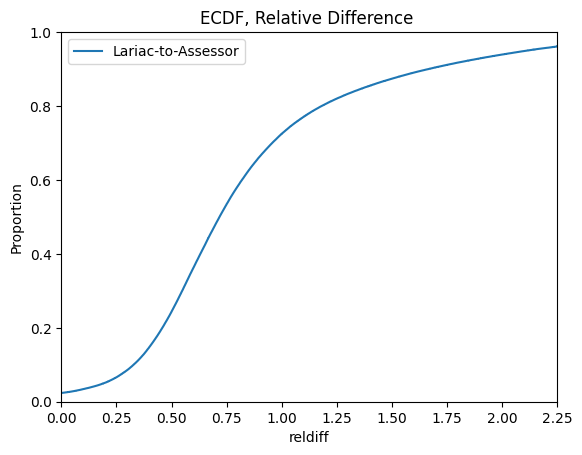

In [ ]:
sns.ecdfplot(data= (df
                    .query('usetype == "Single Family Residence"')
                    .query('LotArea < 10_000')
                    ),
             x = 'reldiff', label = 'Lariac-to-Assessor', legend=True)

# plt.xscale('log')
plt.xlim((0,2))
plt.title('ECDF, Relative Difference ')
# plt.xscale('symlog'), 
plt.xticks(np.arange(0,2.5,.25))
# plt.xlabel('multiple')
plt.legend()

/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


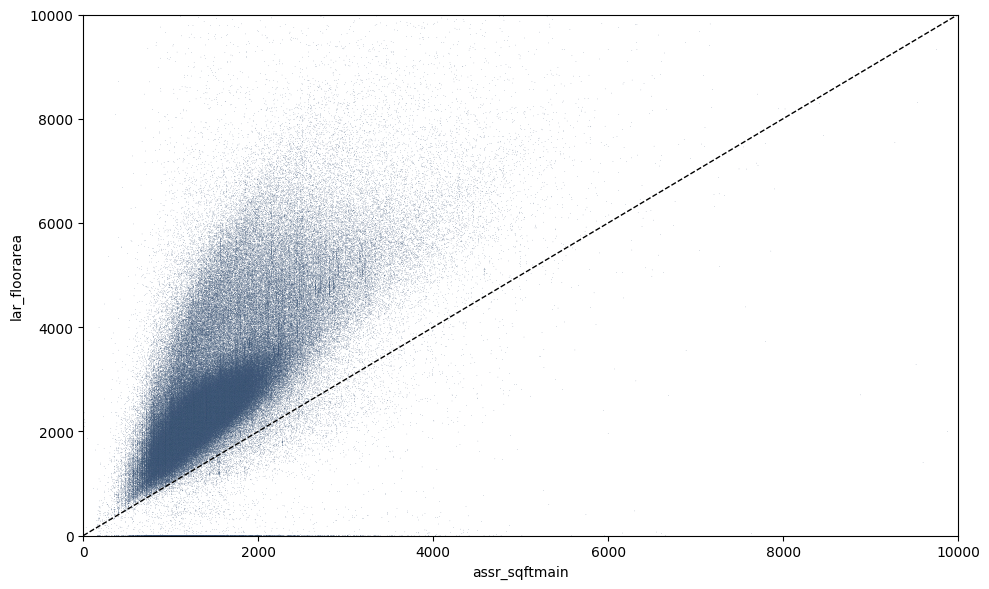

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(data = df
                    .query('usetype == "Single Family Residence"')
                    .query('LotArea < 10_000')
                    .query('lar_n_structures < 6'),
            x= 'assr_sqftmain', y = 'lar_floorarea', 
            hue = 'reldiff', 
            # label = 'LARAIC', 
            legend = False,palette= 'cividis',
            s= .1)

plt.xlim(0,10_000), plt.ylim(0,10_000), 
# plt.xscale('log'), plt.yscale('log')#, plt.ylabel('LAR_')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')
# plt.legend(loc='upper left')
plt.tight_layout()


In [ ]:
z = (df
     .query('usetype == "Single Family Residence"')
     .query('LotArea < 10_000')
     .query('lar_n_structures < 6'))

z = (z['lar_floorarea_max'] < z['assr_sqftmain']).mean()
print(f'Pct. of parcels where assessor greater than lariac: {round(z*100, 2)}%')

Pct. of parcels where assessor greater than lariac: 3.03%


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/mapclassify/classifiers.py:942: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/mapclassify/classifiers.py:972: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam


<Axes: >

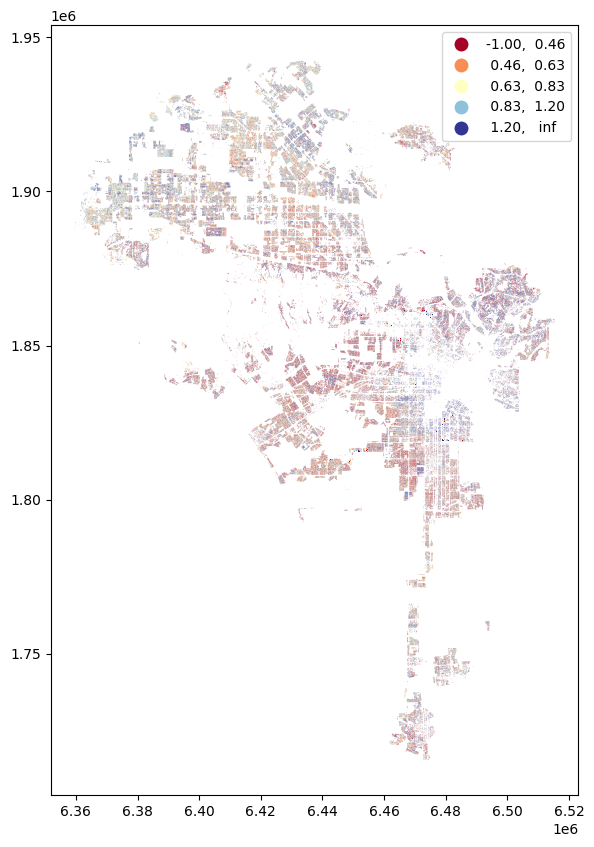

In [ ]:
z = (df
     .query('usetype == "Single Family Residence"')
     .query('LotArea < 10_000')
     .query('lar_n_structures < 6')
     )

z.plot('reldiff', 
       scheme='quantiles',
       cmap = 'RdYlBu', 
     #   vmax=4_000, vmin=-4_000, 
       legend = True,
       figsize=(10,10))